# Using Pretrained Models

This notebook evaluates a pretrained DMRI model on held-out synthetic data. It demonstrates the complete inference workflow without rebuilding the architecture by hand:

1. restore the model and its EMA parameters from a checkpoint,
2. recreate the matching simulator from the saved Hydra config,
3. evaluate model-selection accuracy and negative log probability,
4. inspect parameter uncertainty and posterior-predictive coverage.

> The metrics below use simulated, in-distribution data. They are a useful checkpoint sanity check, not a substitute for validation on independent clinical data.

## 1. Restore a pretrained run

`load_checkpoint` reads the frozen `.hydra/config.yaml`, reconstructs the correct network and simulator family, and restores the requested Orbax checkpoint. EMA parameters are preferred for inference when available.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx

from dmri.train.utils import load_checkpoint


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find the dmri project root.")


CHECKPOINT_NAME = "b3s_2_4_6_64"
HF_REPO_ID = "manugloeck/dmri-pretrained"

if HF_REPO_ID:
    checkpoint, model, simulators = load_checkpoint(
        repo_id=HF_REPO_ID, model_name=CHECKPOINT_NAME, which="best"
    )
else:
    checkpoint_dir = find_project_root() / "results" / CHECKPOINT_NAME
    checkpoint, model, simulators = load_checkpoint(checkpoint_dir, which="best")

params = checkpoint["params_ema"] if "params_ema" in checkpoint else checkpoint["params"]
nnx.update(model, params)
model.eval()

sim_type = model.cfg.simulator
n_params = sum(p.size for p in jax.tree.leaves(nnx.state(model, nnx.Param)))
print(f"run:        {CHECKPOINT_NAME}")
print(f"step:       {checkpoint['step']:,}")
print(f"parameters: {n_params / 1e6:.1f}M")
print(f"theta dim:  {sim_type.theta_dim}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 115 files:   0%|          | 0/115 [00:00<?, ?it/s]

run:        b3s_2_4_6_64
step:       2,640,000
parameters: 2.9M
theta dim:  11


## 2. Create a held-out evaluation set

The loader returns the simulator functions used by the run. The first function corresponds to the 105-measurement HCP acquisition; using it guarantees that model family, acquisition distribution, priors, and noise match training.

In [2]:
num_eval = 128
simulator = simulators[0]
eval_batch = jax.jit(jax.vmap(simulator))(
    jax.random.split(jax.random.key(10), num_eval)
)

raw_names = [cls.__name__ for cls in (*sim_type.model_types, *sim_type.noise_types)]
component_names = []
for i, name in enumerate(raw_names):
    count = raw_names.count(name)
    occurrence = raw_names[: i + 1].count(name)
    component_names.append(f"{name} {occurrence}" if count > 1 else name)

print({k: value.shape for k, value in eval_batch.items() if k != "acq"})
print("components:", component_names)

{'mask_prior': (128, 1), 'model_mask': (128, 5), 'theta': (128, 11), 'x': (128, 105)}
components: ['StaticBall', 'StaticStick 1', 'StaticStick 2', 'StaticStick 3', 'BoundedGaussianNoise']


## 3. Evaluate model selection

`sample_mask` draws a component mask from the learned model-selection posterior. The three `StaticStick` slots are exchangeable in this simulator: masks that differ only by a permutation of active sticks generate the same model family. The single noise component is always active. We therefore evaluate the seven identifiable classes defined by ball presence and the number of active sticks, rather than treating all 15 labeled masks as distinct.

The baseline below is an independent draw from the actual mask prior at each sample's supplied prior hyperparameter. This is more meaningful than a fixed 0.5 line because the forced-active signal component and always-active noise component make the mask bits non-uniform.

In [3]:
pred_masks = jax.vmap(model.sample_mask, in_axes=(0, 0, 0, 0))(
    jax.random.split(jax.random.key(11), num_eval),
    eval_batch["acq"],
    eval_batch["x"],
    eval_batch["mask_prior"],
)
true_mask_log_prob = jax.vmap(model.log_prob_mask, in_axes=(0, 0, 0, 0))(
    eval_batch["model_mask"],
    eval_batch["acq"],
    eval_batch["x"],
    eval_batch["mask_prior"],
)

# Canonical class: four stick counts for ball-present masks and three for
# ball-absent masks. Class 0 (no signal compartment) is not feasible.
def model_class(mask):
    ball_present = mask[..., 0].astype(jnp.int32)
    stick_count = mask[..., 1:4].sum(axis=-1).astype(jnp.int32)
    return 4 * ball_present + stick_count


true_classes = model_class(eval_batch["model_mask"])
pred_classes = model_class(pred_masks)
class_matches = pred_classes == true_classes
exact_matches = (pred_masks == eval_batch["model_mask"]).all(-1)

# A prior-only classifier knows the supplied mask prior but not the signal.
prior_masks = jax.vmap(simulator, in_axes=(0, 0))(
    jax.random.split(jax.random.key(14), num_eval), eval_batch["mask_prior"]
)["model_mask"]
prior_class_accuracy = (model_class(prior_masks) == true_classes).mean()

# Sum probability over every labeled stick mask in the true equivalence class.
stick_patterns = (
    (jnp.arange(8)[:, None] >> jnp.arange(3)[None, :]) & 1
).astype(bool)


def equivalent_class_log_prob(true_mask, acq, x, mask_prior):
    candidates = jnp.concatenate(
        [
            jnp.broadcast_to(true_mask[None, :1], (8, 1)),
            stick_patterns,
            jnp.broadcast_to(true_mask[None, 4:], (8, 1)),
        ],
        axis=-1,
    )
    log_probs = jax.vmap(model.log_prob_mask, in_axes=(0, None, None, None))(
        candidates, acq, x, mask_prior
    )
    same_class = stick_patterns.sum(axis=-1) == true_mask[1:4].sum()
    return jax.scipy.special.logsumexp(jnp.where(same_class, log_probs, -jnp.inf))


class_log_prob = jax.vmap(equivalent_class_log_prob)(
    eval_batch["model_mask"],
    eval_batch["acq"],
    eval_batch["x"],
    eval_batch["mask_prior"],
)

print(f"equivalence-class accuracy: {class_matches.mean():.3f}")
print(f"prior-only class baseline:  {prior_class_accuracy:.3f}")
print(f"equivalence-class NLL:      {-class_log_prob.mean():.3f}")
print(f"label-exact mask accuracy:  {exact_matches.mean():.3f}")
print(f"label-exact mask NLL:       {-true_mask_log_prob.mean():.3f}")

equivalence-class accuracy: 0.617
prior-only class baseline:  0.328
equivalence-class NLL:      0.719
label-exact mask accuracy:  0.398
label-exact mask NLL:       1.395


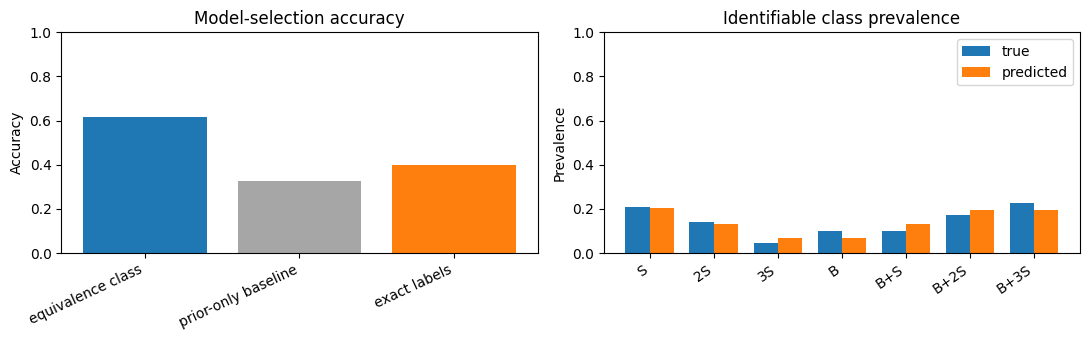

In [4]:
class_ids = np.arange(1, 8)
class_names = ["S", "2S", "3S", "B", "B+S", "B+2S", "B+3S"]
width = 0.38
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(
    [0, 1, 2],
    [class_matches.mean(), prior_class_accuracy, exact_matches.mean()],
    color=["C0", "0.65", "C1"],
)
axes[0].set_xticks(
    [0, 1, 2], ["equivalence class", "prior-only baseline", "exact labels"], rotation=25, ha="right"
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model-selection accuracy")

true_frequency = jnp.array([(true_classes == class_id).mean() for class_id in class_ids])
pred_frequency = jnp.array([(pred_classes == class_id).mean() for class_id in class_ids])
axes[1].bar(class_ids - width / 2, true_frequency, width, label="true")
axes[1].bar(class_ids + width / 2, pred_frequency, width, label="predicted")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Prevalence")
axes[1].set_title("Identifiable class prevalence")
axes[1].set_xticks(class_ids, class_names, rotation=35, ha="right")
axes[1].legend()

plt.tight_layout()

## 4. Evaluate parameter uncertainty

To separate parameter inference from model-selection errors, select an exactly classified sample and condition `sample_theta` on its predicted mask. The plot compares the posterior median and 90% interval with the known simulator parameters.

In [5]:
active_components = eval_batch["model_mask"].sum(-1)
candidate_score = jnp.where(exact_matches, active_components, -1)
sample_idx = int(jnp.argmax(candidate_score))

acq = jax.tree_util.tree_map(lambda value: value[sample_idx], eval_batch["acq"])
x = eval_batch["x"][sample_idx]
theta_true = eval_batch["theta"][sample_idx]
model_mask = pred_masks[sample_idx]

theta_samples = jax.vmap(
    lambda key: model.sample_theta(key, acq, x, model_mask, num_steps=32)
)(jax.random.split(jax.random.key(12), 256))

lower, median, upper = jnp.quantile(theta_samples, jnp.array([0.05, 0.5, 0.95]), axis=0)
coverage = ((theta_true >= lower) & (theta_true <= upper)).mean()
print(f"sample index:          {sample_idx}")
print(f"model mask:           {np.asarray(model_mask)}")
print(f"90% interval coverage: {coverage:.3f}")

sample index:          6
model mask:           [ True  True  True  True  True]
90% interval coverage: 0.909


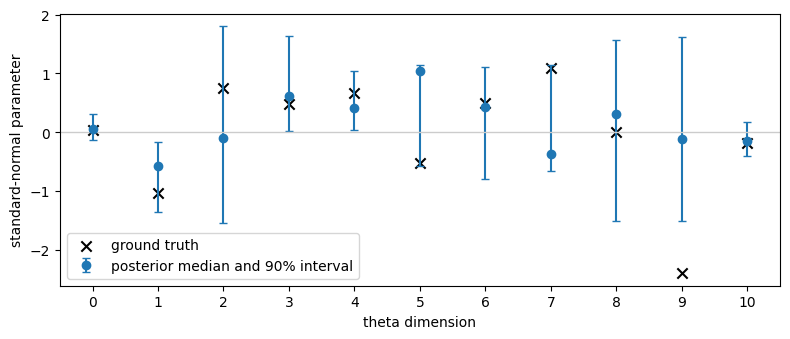

In [6]:
theta_index = np.arange(sim_type.theta_dim)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(
    theta_index,
    median,
    yerr=np.stack([median - lower, upper - median]),
    fmt="o",
    capsize=3,
    label="posterior median and 90% interval",
)
ax.scatter(theta_index, theta_true, color="black", marker="x", s=55, label="ground truth")
ax.axhline(0, color="0.8", lw=1)
ax.set_xlabel("theta dimension")
ax.set_ylabel("standard-normal parameter")
ax.set_xticks(theta_index)
ax.legend()
plt.tight_layout()

## 5. Posterior-predictive evaluation

Push posterior samples back through the physical simulator. The median and 90% predictive band should explain the observed signal across b-values.

posterior-predictive MSE: 0.00083


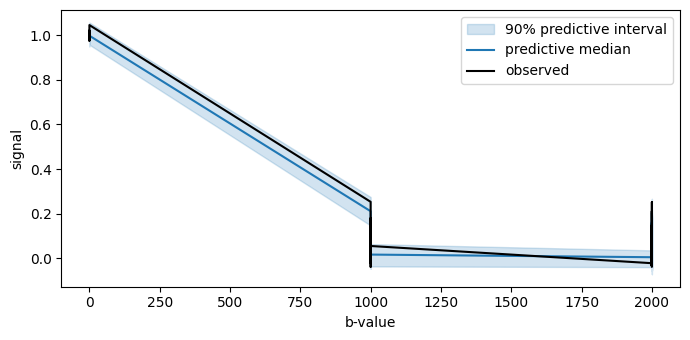

In [7]:
def predict_signal(theta, rng):
    physical_model = sim_type.from_theta(theta, model_mask=model_mask)
    return physical_model.signal(acq, rng=rng)


predictive = jax.vmap(predict_signal)(
    theta_samples[:100], jax.random.split(jax.random.key(13), 100)
)
pred_lower, pred_median, pred_upper = jnp.quantile(
    predictive, jnp.array([0.05, 0.5, 0.95]), axis=0
)
predictive_mse = jnp.mean((predictive.mean(0) - x) ** 2)
print(f"posterior-predictive MSE: {predictive_mse:.5f}")

order = jnp.argsort(acq.bvals)
bvals = np.asarray(acq.bvals)[order]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.fill_between(bvals, pred_lower[order], pred_upper[order], color="C0", alpha=0.2, label="90% predictive interval")
ax.plot(bvals, pred_median[order], color="C0", lw=1.5, label="predictive median")
ax.plot(bvals, np.asarray(x)[order], color="black", lw=1.5, label="observed")
ax.set_xlabel("b-value")
ax.set_ylabel("signal")
ax.legend()
plt.tight_layout()

## Next steps

- Change `CHECKPOINT_NAME` to evaluate another compatible run; the loader reconstructs its architecture automatically.
- Use `which="latest"`, `which="best"`, or an integer step to choose the checkpoint.
- For NIfTI data, model averaging, SMC/MCMC correction, and metric exports, use the `dmri_eval` CLI described in the *Evaluation & Export* guide.
- The standalone training example shows how to train a small model on fresh simulations and evaluate its held-out predictions.